# QROM T-count Scaling (Random Data)

This notebook benchmarks Qualtran `QROM` on random classical tables and estimates T-count scaling with data size.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

from qualtran.bloqs.data_loading.qrom import QROM
from qualtran.resource_counting import QECGatesCost, get_cost_value

REPO_ROOT = Path.cwd()
if (REPO_ROOT / 'src').exists():
    SRC_DIR = REPO_ROOT / 'src'
elif (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
    SRC_DIR = REPO_ROOT / 'src'
else:
    raise RuntimeError('Could not find repo root containing src/.')

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

np.random.seed(1234)

In [2]:
def qec_counts_for_qrom(data: np.ndarray):
    qrom = QROM.build_from_data(data.astype(np.int64))
    gc = get_cost_value(qrom, QECGatesCost())
    d = gc.asdict() if hasattr(gc, 'asdict') else vars(gc)
    toff_like = int(d.get('toffoli', 0) + d.get('and_bloq', 0) + d.get('cswap', 0))
    # Standard rough mapping: 1 Toffoli-like ~ 4 T gates
    t_est = 4 * toff_like
    return d, toff_like, t_est

# Sweep table length N; each entry is a random b-bit integer.
bitsize = 10
N_list = [2**k for k in range(4, 15)]  # 16 ... 16384

rows = []
for N in N_list:
    data = np.random.randint(0, 2**bitsize, size=(N,), dtype=np.int64)
    qec, toff_like, t_est = qec_counts_for_qrom(data)
    rows.append({
        'N': N,
        'and_bloq': int(qec.get('and_bloq', 0)),
        'toffoli': int(qec.get('toffoli', 0)),
        'clifford': int(qec.get('clifford', 0)),
        'rotation': int(qec.get('rotation', 0)),
        'toffoli_like': toff_like,
        'T_est': t_est,
    })

rows[:3], rows[-1]

([{'N': 16,
   'and_bloq': 14,
   'toffoli': 0,
   'clifford': 112,
   'rotation': 0,
   'toffoli_like': 14,
   'T_est': 56},
  {'N': 32,
   'and_bloq': 30,
   'toffoli': 0,
   'clifford': 226,
   'rotation': 0,
   'toffoli_like': 30,
   'T_est': 120},
  {'N': 64,
   'and_bloq': 62,
   'toffoli': 0,
   'clifford': 477,
   'rotation': 0,
   'toffoli_like': 62,
   'T_est': 248}],
 {'N': 16384,
  'and_bloq': 16380,
  'toffoli': 0,
  'clifford': 114459,
  'rotation': 0,
  'toffoli_like': 16380,
  'T_est': 65520})

Fit: T_est ~ 3.58 * N^1.0138


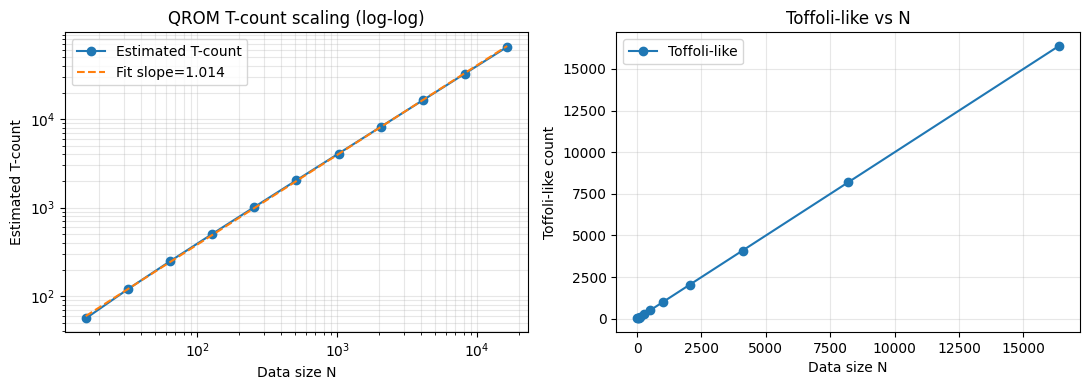

In [3]:
N = np.array([r['N'] for r in rows], dtype=float)
T_est = np.array([r['T_est'] for r in rows], dtype=float)
toff_like = np.array([r['toffoli_like'] for r in rows], dtype=float)

# Fit power law: T_est ~ c * N^alpha
alpha, log_c = np.polyfit(np.log(N), np.log(np.maximum(T_est, 1.0)), 1)
c = float(np.exp(log_c))

print(f'Fit: T_est ~ {c:.3g} * N^{alpha:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].loglog(N, T_est, 'o-', label='Estimated T-count')
ax[0].loglog(N, c * (N ** alpha), '--', label=f'Fit slope={alpha:.3f}')
ax[0].set_xlabel('Data size N')
ax[0].set_ylabel('Estimated T-count')
ax[0].set_title('QROM T-count scaling (log-log)')
ax[0].grid(True, which='both', alpha=0.3)
ax[0].legend()

ax[1].plot(N, toff_like, 'o-', label='Toffoli-like')
ax[1].set_xlabel('Data size N')
ax[1].set_ylabel('Toffoli-like count')
ax[1].set_title('Toffoli-like vs N')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [4]:
print('N, and_bloq, toffoli, clifford, rotation, toffoli_like, T_est')
for r in rows:
    print(f"{r['N']:6d}, {r['and_bloq']:8d}, {r['toffoli']:7d}, {r['clifford']:9d}, {r['rotation']:8d}, {r['toffoli_like']:12d}, {r['T_est']:8d}")

N, and_bloq, toffoli, clifford, rotation, toffoli_like, T_est
    16,       14,       0,       112,        0,           14,       56
    32,       30,       0,       226,        0,           30,      120
    64,       62,       0,       477,        0,           62,      248
   128,      126,       0,       875,        0,          126,      504
   256,      254,       0,      1835,        0,          254,     1016
   512,      510,       0,      3598,        0,          510,     2040
  1024,     1022,       0,      7125,        0,         1022,     4088
  2048,     2046,       0,     14373,        0,         2046,     8184
  4096,     4092,       0,     28620,        0,         4092,    16368
  8192,     8186,       0,     57339,        0,         8186,    32744
 16384,    16380,       0,    114459,        0,        16380,    65520
